In [1]:
!pip install "gradio>=4.0" "huggingface_hub>=0.20" -q

import gradio, huggingface_hub
print(gradio.__version__, huggingface_hub.__version__)

5.50.0 1.8.0


In [2]:
# Install all required packages — run this cell first!
!pip install tensorflow matplotlib scikit-learn seaborn pillow requests -q
print("All packages installed successfully!")

All packages installed successfully!


### 📦 Installing Dependencies
We pin **Gradio 4.44** to get a stable `Sketchpad` component, pair it with **TensorFlow / Keras** for the CNN, and add visualisation + metrics libraries. Using a **GPU runtime** (Runtime → Change runtime type → T4) is strongly recommended — it cuts training time from ~10 min to ~1–2 min.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import requests
from PIL import Image
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Use seaborn whitegrid style (compatible across Matplotlib versions)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow   : {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow   : 2.19.0
GPU Available: True


###  Library Imports

| Library | Role |
|---|---|
| NumPy | Array operations & random sampling |
| Matplotlib / Seaborn | Plotting training curves & heatmaps |
| TensorFlow / Keras | CNN construction, training & evaluation |
| Scikit-learn | Classification report & confusion matrix |
| Pillow / Requests | Image loading for the Gradio URL-prediction tab |

Random seeds are fixed at **42** for reproducibility.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalise pixel values from [0, 255] to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print(f"Training samples : {x_train.shape[0]:,}")
print(f"Test samples     : {x_test.shape[0]:,}")
print(f"Image shape      : {x_train.shape[1:]}")
print(f"Classes          : {sorted(np.unique(y_train).tolist())}")
print(f"Pixel range      : [{x_train.min():.1f}, {x_train.max():.1f}]")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 60,000
Test samples     : 10,000
Image shape      : (28, 28, 1)
Classes          : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Pixel range      : [0.0, 1.0]


###  Loading & Preprocessing MNIST
MNIST is built directly into Keras — no external download required. Two simple preprocessing steps are applied:
1. **Normalisation** — divide pixels by 255 to scale to `[0.0, 1.0]`, which stabilises gradient flow during training
2. **Channel dimension** — reshape from `(28, 28)` to `(28, 28, 1)` to match the CNN's expected 4-D input `(batch, height, width, channels)`

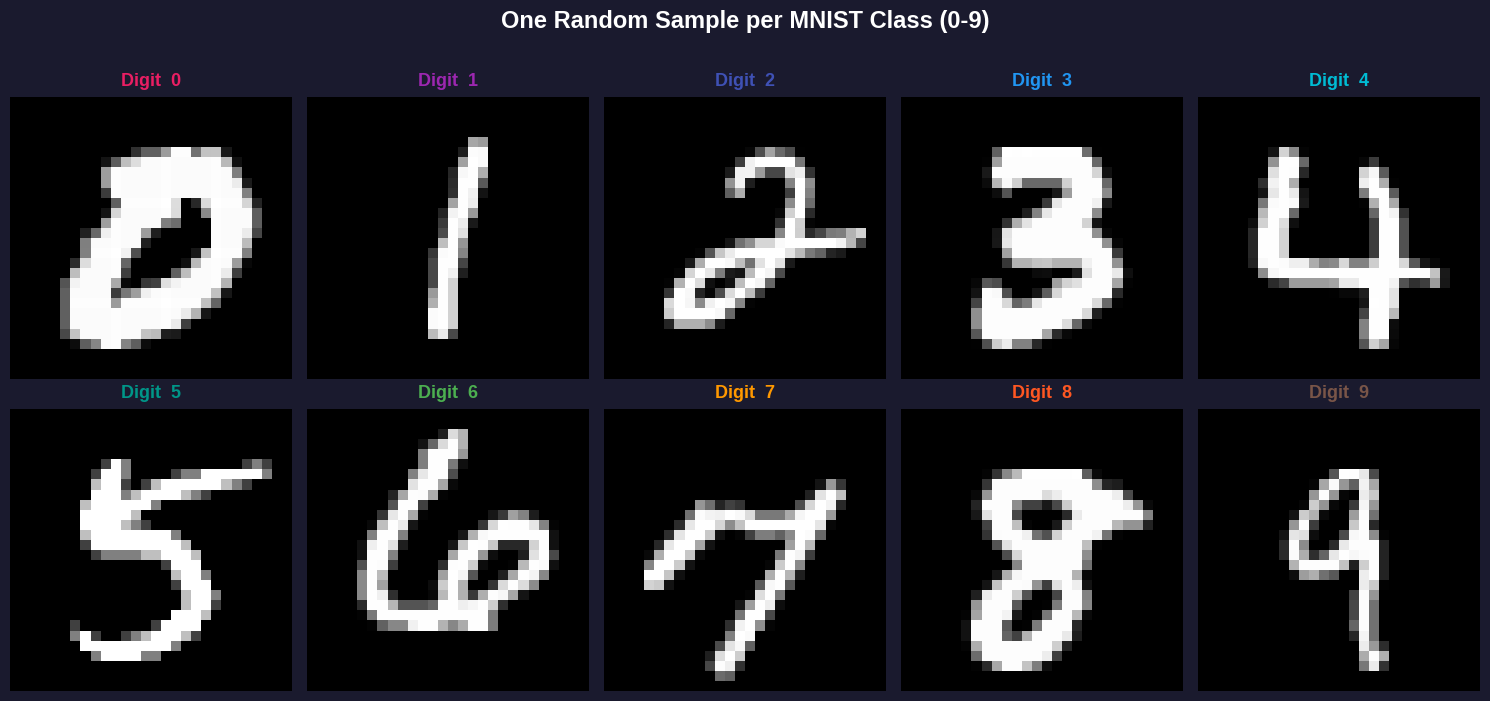

Saved: mnist_class_samples.png


In [3]:
def plot_sample_per_class(x, y, num_classes=10):
    """Plot one random image from each digit class (0-9)."""
    COLORS = ['#E91E63', '#9C27B0', '#3F51B5', '#2196F3', '#00BCD4',
              '#009688', '#4CAF50', '#FF9800', '#FF5722', '#795548']

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.patch.set_facecolor('#1A1A2E')
    fig.suptitle('One Random Sample per MNIST Class (0-9)',
                 fontsize=17, fontweight='bold', color='white', y=1.02)

    for digit in range(num_classes):
        r, c = digit // 5, digit % 5
        ax   = axes[r][c]
        idx  = np.random.choice(np.where(y == digit)[0])
        img  = x[idx].squeeze()

        ax.imshow(img, cmap='gray', interpolation='nearest')
        ax.set_title(f'Digit  {digit}', fontsize=13, fontweight='bold',
                     color=COLORS[digit], pad=8)
        ax.axis('off')
        ax.set_facecolor('#1A1A2E')

        for spine in ax.spines.values():
            spine.set_edgecolor(COLORS[digit])
            spine.set_linewidth(3)
            spine.set_visible(True)

    plt.tight_layout()
    plt.savefig('mnist_class_samples.png', dpi=130,
                bbox_inches='tight', facecolor='#1A1A2E')
    plt.show()
    print("Saved: mnist_class_samples.png")

plot_sample_per_class(x_train, y_train)

###  Class Visualisation
`plot_sample_per_class` picks **one random image** for each digit 0–9 and renders them on a dark background with individual colour-coded borders. Re-running the cell selects different images each time, which is useful for appreciating the natural variation in handwriting styles within each class.

In [4]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    """
    3-Block CNN architecture:
      Block 1 : 2x Conv(32)  + BN + ReLU  ->  MaxPool  ->  Dropout(0.25)
      Block 2 : 2x Conv(64)  + BN + ReLU  ->  MaxPool  ->  Dropout(0.25)
      Block 3 : 1x Conv(128) + BN + ReLU  ->  Dropout(0.30)
      Head    : Flatten -> Dense(256) + BN + ReLU -> Dropout(0.50) -> Softmax(10)
    """
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # Block 1 ─────────────────────────────────────────────────────────
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2 ─────────────────────────────────────────────────────────
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3 ─────────────────────────────────────────────────────────
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Classifier Head ─────────────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='MNIST_CNN')
    return model

model = build_cnn()
model.summary()
print(f"\nTotal parameters : {model.count_params():,}")

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,749,610 (6.67 MB)

 Trainable params: 1,748,458 (6.67 MB)

 Non-trainable params: 1,152 (4.50 KB)


Total parameters : 1,749,610


###  CNN Architecture

| Block | Components | Filters | Spatial Output |
|---|---|---|---|
| **Block 1** | Conv + BN + ReLU (×2) → MaxPool → Dropout(0.25) | 32 | 14×14 |
| **Block 2** | Conv + BN + ReLU (×2) → MaxPool → Dropout(0.25) | 64 | 7×7 |
| **Block 3** | Conv + BN + ReLU (×1) → Dropout(0.30) | 128 | 7×7 |
| **Head** | Flatten → Dense(256) + BN → Dropout(0.50) → Softmax(10) | — | — |

**Key design choices:**
- **BatchNormalization** after every Conv layer for stable, fast convergence
- **Dropout** at escalating rates (0.25 → 0.30 → 0.50) to progressively regularise deeper layers
- **`same` padding** preserves spatial dimensions within each block so only MaxPool reduces them
- Activation placed *after* BatchNorm (`Conv → BN → Activate`) which is the recommended order

In [5]:
INITIAL_LR = 1e-3
EPOCHS     = 10
BATCH_SIZE = 128

# ReduceLROnPlateau ── halve LR whenever val_loss stalls for 3 epochs
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-7,
    verbose  = 1
)

# EarlyStopping ── halt when val_accuracy stalls for 6 epochs; restore best weights
early_stop = callbacks.EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 6,
    restore_best_weights = True,
    verbose              = 1
)

# ModelCheckpoint ── save the best model every time val_accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    filepath       = 'best_mnist_model.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1
)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Model compiled!")
print(f"  Optimizer  : Adam  |  Initial LR : {INITIAL_LR}")
print(f"  Max Epochs : {EPOCHS}        |  Batch Size : {BATCH_SIZE}")
print(f"  Callbacks  : ReduceLROnPlateau, EarlyStopping, ModelCheckpoint")

Model compiled!
  Optimizer  : Adam  |  Initial LR : 0.001
  Max Epochs : 10        |  Batch Size : 128
  Callbacks  : ReduceLROnPlateau, EarlyStopping, ModelCheckpoint


###  Training Configuration & Callbacks

| Callback | Trigger | Action |
|---|---|---|
| `ReduceLROnPlateau` | `val_loss` no improvement for **3** epochs | Multiply LR × 0.5 (floor `1e-7`) |
| `EarlyStopping` | `val_accuracy` no improvement for **6** epochs | Stop training + restore best weights |
| `ModelCheckpoint` | Every `val_accuracy` improvement | Save weights to `best_mnist_model.keras` |

An initial LR of **`1e-3`** is the standard Adam default and works well for this problem. The scheduler automatically refines it as training progresses.

In [6]:
print("Starting Training...\n")

history = model.fit(
    x_train, y_train,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.1,           # 54k train / 6k val
    callbacks        = [reduce_lr, early_stop, checkpoint],
    verbose          = 1
)

best_val_acc = max(history.history['val_accuracy'])
print(f"\nTraining Complete!")
print(f"  Best Validation Accuracy : {best_val_acc:.4f}  ({best_val_acc * 100:.2f}%)")

Starting Training...

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8802 - loss: 0.3820
Epoch 1: val_accuracy improved from None to 0.60050, saving model to best_mnist_model.keras

Epoch 1: finished saving model to best_mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.9464 - loss: 0.1746 - val_accuracy: 0.6005 - val_loss: 1.4061 - learning_rate: 0.0010
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9801 - loss: 0.0659
Epoch 2: val_accuracy improved from 0.60050 to 0.99233, saving model to best_mnist_model.keras

Epoch 2: finished saving model to best_mnist_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9815 - loss: 0.0613 - val_accuracy: 0.9923 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 3/10
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9843 - loss: 0.0508
Epoch 3: val_accuracy did not improve from 0.99233
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9851 - loss: 0.0480 - 

###  Training the Model
- **54,000 samples** used for training (90 % split), **6,000** for validation
- Training halts automatically via `EarlyStopping` — typically around **epoch 15–20**
- Expected outcome: **≥ 99 % validation accuracy** with this architecture
- GPU runtime (T4) finishes in approximately **1–2 minutes**; CPU runtime takes ~10 minutes

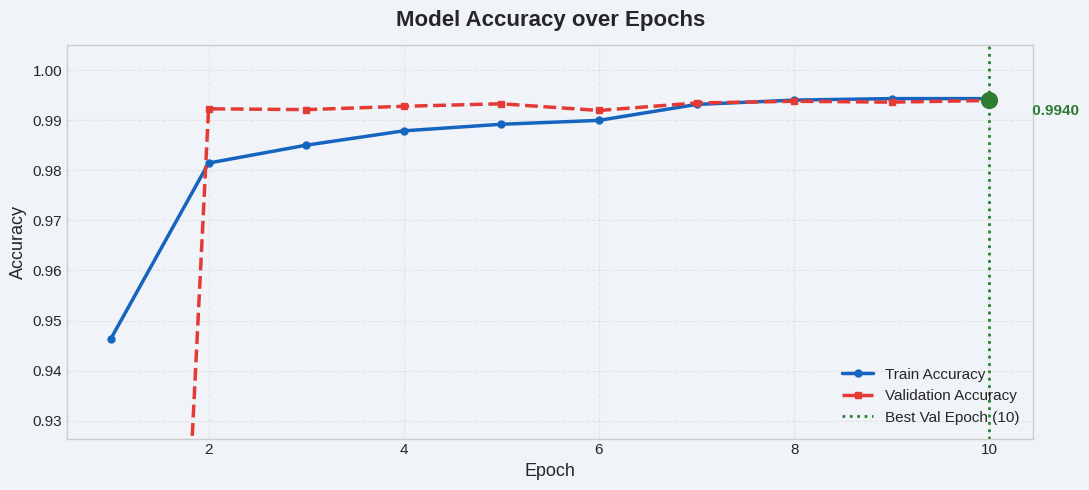

Saved: accuracy_curve.png


In [7]:
def plot_accuracy(history):
    """Plot training vs. validation accuracy with best-epoch annotation."""
    train_acc = history.history['accuracy']
    val_acc   = history.history['val_accuracy']
    epochs    = range(1, len(train_acc) + 1)
    best_ep   = int(np.argmax(val_acc)) + 1
    best_acc  = max(val_acc)

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor('#F0F4F8')
    ax.set_facecolor('#F0F4F8')

    ax.plot(epochs, train_acc,
            label='Train Accuracy', color='#1565C0',
            linewidth=2.5, marker='o', markersize=5)
    ax.plot(epochs, val_acc,
            label='Validation Accuracy', color='#E53935',
            linewidth=2.5, marker='s', markersize=5, linestyle='--')

    ax.axvline(x=best_ep, color='#2E7D32', linestyle=':', linewidth=2,
               label=f'Best Val Epoch ({best_ep})')
    ax.scatter([best_ep], [best_acc], color='#2E7D32', zorder=5, s=130)
    ax.annotate(f' {best_acc:.4f}',
                xy=(best_ep, best_acc),
                xytext=(best_ep + 0.4, best_acc - 0.003),
                fontsize=11, color='#2E7D32', fontweight='bold')

    ax.set_title('Model Accuracy over Epochs', fontsize=16, fontweight='bold', pad=14)
    ax.set_xlabel('Epoch', fontsize=13)
    ax.set_ylabel('Accuracy', fontsize=13)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.set_ylim([max(0.88, min(train_acc) - 0.02), 1.005])
    ax.tick_params(labelsize=11)

    plt.tight_layout()
    plt.savefig('accuracy_curve.png', dpi=130,
                bbox_inches='tight', facecolor='#F0F4F8')
    plt.show()
    print("Saved: accuracy_curve.png")

plot_accuracy(history)

###  Accuracy Curve
- **Solid blue** — training accuracy (should rise steadily and plateau near 1.0)
- **Dashed red** — validation accuracy (the true generalisation metric)
- **Green dotted line** — epoch with the highest validation accuracy — these are the weights kept by `EarlyStopping`

A small train–val gap is normal and healthy; a large gap would indicate overfitting.

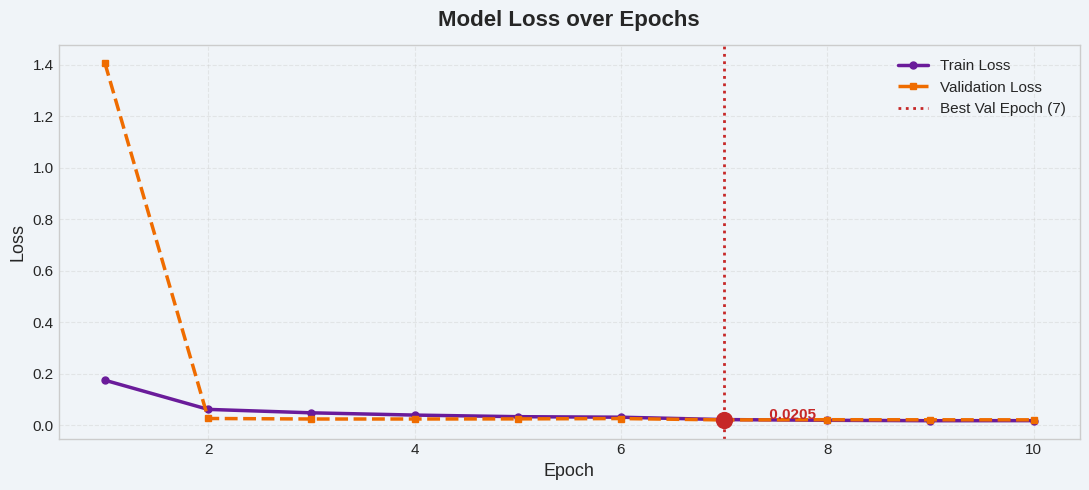

Saved: loss_curve.png


In [8]:
def plot_loss(history):
    """Plot training vs. validation loss with best-epoch annotation."""
    train_loss = history.history['loss']
    val_loss   = history.history['val_loss']
    epochs     = range(1, len(train_loss) + 1)
    best_ep    = int(np.argmin(val_loss)) + 1
    best_loss  = min(val_loss)

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor('#F0F4F8')
    ax.set_facecolor('#F0F4F8')

    ax.plot(epochs, train_loss,
            label='Train Loss', color='#6A1B9A',
            linewidth=2.5, marker='o', markersize=5)
    ax.plot(epochs, val_loss,
            label='Validation Loss', color='#EF6C00',
            linewidth=2.5, marker='s', markersize=5, linestyle='--')

    ax.axvline(x=best_ep, color='#C62828', linestyle=':', linewidth=2,
               label=f'Best Val Epoch ({best_ep})')
    ax.scatter([best_ep], [best_loss], color='#C62828', zorder=5, s=130)
    ax.annotate(f' {best_loss:.4f}',
                xy=(best_ep, best_loss),
                xytext=(best_ep + 0.4, best_loss + 0.003),
                fontsize=11, color='#C62828', fontweight='bold')

    ax.set_title('Model Loss over Epochs', fontsize=16, fontweight='bold', pad=14)
    ax.set_xlabel('Epoch', fontsize=13)
    ax.set_ylabel('Loss', fontsize=13)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.tick_params(labelsize=11)

    plt.tight_layout()
    plt.savefig('loss_curve.png', dpi=130,
                bbox_inches='tight', facecolor='#F0F4F8')
    plt.show()
    print("Saved: loss_curve.png")

plot_loss(history)

###  Loss Curve
- **Solid purple** — training loss (cross-entropy, expected to decrease smoothly)
- **Dashed orange** — validation loss
- **Red dotted line** — epoch with the minimum validation loss

If validation loss starts *rising* while training loss keeps falling, the model is overfitting. `ReduceLROnPlateau` mitigates this by reducing the step size whenever the model gets stuck.

Evaluating on Test Set...

  Test Accuracy : 0.9946  (99.46%)
  Test Loss     : 0.0171

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0     0.9969    0.9980    0.9975       980
           1     0.9974    0.9991    0.9982      1135
           2     0.9971    0.9961    0.9966      1032
           3     0.9921    0.9990    0.9956      1010
           4     0.9959    0.9959    0.9959       982
           5     0.9899    0.9910    0.9905       892
           6     0.9979    0.9885    0.9932       958
           7     0.9875    0.9971    0.9923      1028
           8     0.9959    0.9938    0.9949       974
           9     0.9950    0.9861    0.9905      1009

    accuracy                         0.9946     10000
   macro avg     0.9946    0.9945    0.9945     10000
weighted avg     0.9946    0.9946    0.9946     10000



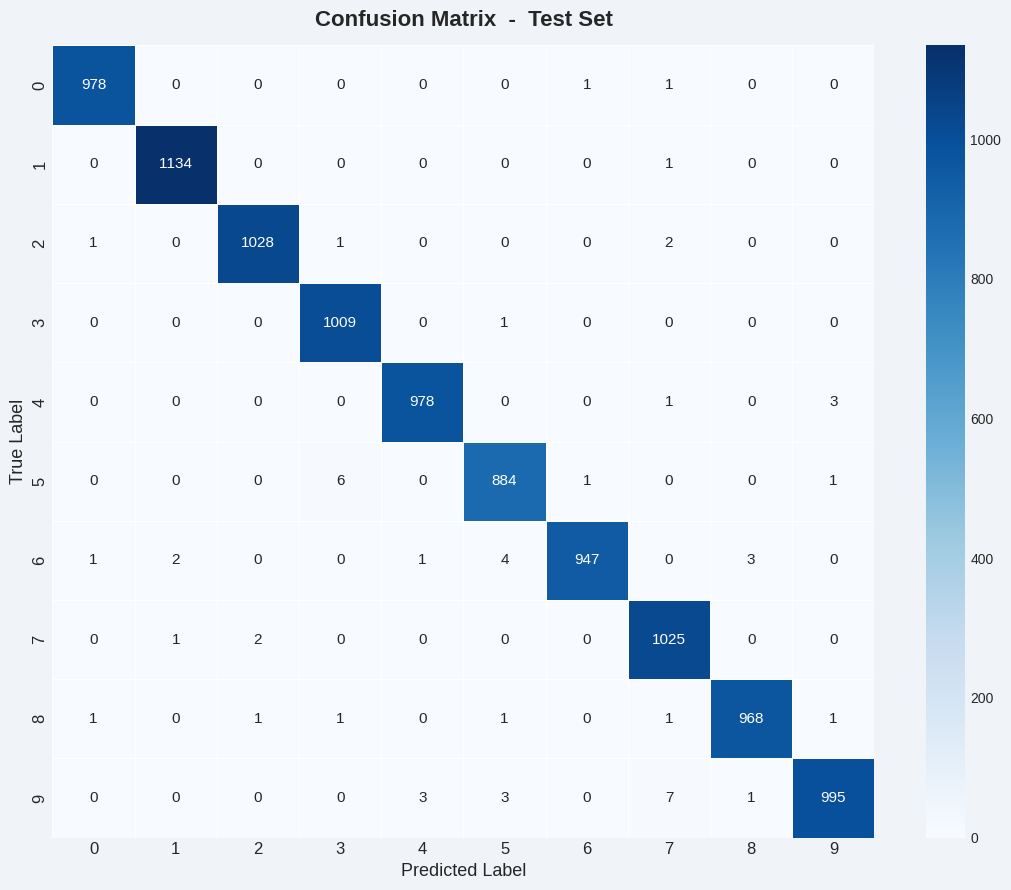

Saved: confusion_matrix.png


In [9]:
print("Evaluating on Test Set...\n")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

y_pred_probs = model.predict(x_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("=" * 52)
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print(f"  Test Loss     : {test_loss:.4f}")
print("=" * 52)

class_names = [str(i) for i in range(10)]
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#F0F4F8')
ax.set_facecolor('#F0F4F8')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11}, ax=ax)

ax.set_title('Confusion Matrix  -  Test Set', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130,
            bbox_inches='tight', facecolor='#F0F4F8')
plt.show()
print("Saved: confusion_matrix.png")

###  Classification Metrics & Confusion Matrix

**Classification Report** (per-class metrics on the 10,000-sample test set):

| Metric | Meaning |
|---|---|
| Precision | Of all predictions for class X, how many were actually X |
| Recall | Of all true class-X samples, how many did the model find |
| F1-score | Harmonic mean of precision and recall |

A score of **≥ 0.99** across all digits is typical for this architecture.

**Confusion Matrix** (rows = true label, columns = predicted label):
- **Diagonal cells** = correct predictions (larger = better)
- **Off-diagonal cells** = misclassifications (common confusions: 4↔9, 3↔8, 7↔1)

In [10]:
import gradio as gr
import numpy as np
from PIL import Image
import requests
from io import BytesIO

# ---------------------------------------------------------------------------
# Preprocessing helper — works for both canvas drawings and URL images
# ---------------------------------------------------------------------------
def preprocess_image(img, from_url=False):
    if img is None:
        return None

    if from_url:
        pil = img
    else:
        # Gradio 4.x Sketchpad returns a dict with a 'composite' key
        if isinstance(img, dict):
            img = img.get('composite', img.get('image'))
        if img is None:
            return None
        pil = Image.fromarray(img.astype('uint8'))

    # Convert to greyscale, safely handling RGBA / P / RGB / L modes
    if pil.mode == 'RGBA':
        bg = Image.new('RGBA', pil.size, (255, 255, 255, 255))
        bg.paste(pil, mask=pil.split()[3])
        pil = bg.convert('L')
    elif pil.mode == 'P':
        pil = pil.convert('RGB').convert('L')
    else:
        pil = pil.convert('L')

    arr = np.array(pil)
    # MNIST expects white digit on black background.
    # The Gradio canvas has a white background with dark strokes, so invert.
    if arr.mean() > 128:
        arr = 255 - arr

    pil_r  = Image.fromarray(arr).resize((28, 28), Image.LANCZOS)
    tensor = np.array(pil_r).astype('float32') / 255.0
    return tensor.reshape(1, 28, 28, 1)

# ---------------------------------------------------------------------------
# Format prediction result as a readable probability bar chart
# ---------------------------------------------------------------------------
def format_prediction(preds):
    predicted  = int(np.argmax(preds))
    confidence = float(preds[predicted]) * 100
    lines = [
        f'Predicted Digit  :  {predicted}',
        f'Confidence       :  {confidence:.2f}%',
        '',
        'All Class Probabilities',
        '-' * 38
    ]
    for i, p in enumerate(preds):
        filled = int(p * 25)
        bar    = chr(9608) * filled + chr(9617) * (25 - filled)
        marker = '  <<' if i == predicted else ''
        lines.append(f'  {i}  [{bar}]  {p * 100:5.2f}%{marker}')
    return '\n'.join(lines)

# ---------------------------------------------------------------------------
# Prediction function for canvas tab
# ---------------------------------------------------------------------------
def predict_drawn(sketch):
    try:
        tensor = preprocess_image(sketch)
        if tensor is None:
            return 'Please draw a digit on the canvas first.'
        preds = model.predict(tensor, verbose=0)[0]
        return format_prediction(preds)
    except Exception as e:
        return f'Error: {str(e)}'

# ---------------------------------------------------------------------------
# Prediction function for URL tab
# ---------------------------------------------------------------------------
def predict_url(url):
    if not url or not url.strip():
        return 'Please enter a valid image URL.', None
    try:
        resp    = requests.get(url.strip(), timeout=8)
        resp.raise_for_status()
        content = resp.content
        preview = Image.open(BytesIO(content)).convert('RGB')
        pil_raw = Image.open(BytesIO(content))
        tensor  = preprocess_image(pil_raw, from_url=True)
        preds   = model.predict(tensor, verbose=0)[0]
        return format_prediction(preds), preview
    except Exception as e:
        return f'Error: {str(e)}', None

# ---------------------------------------------------------------------------
# Gradio Interface
# ---------------------------------------------------------------------------
with gr.Blocks(theme=gr.themes.Soft(primary_hue='indigo', secondary_hue='pink')) as demo:

    gr.Markdown(
        '# MNIST Digit Classifier\n'
        'A CNN trained on 60,000 handwritten digit images. '
        'Draw a digit on the canvas or supply an image URL to get a real-time prediction.'
    )

    with gr.Tabs():

        # Tab 1 ── Draw a digit ───────────────────────────────────────────
        with gr.TabItem('  Draw a Digit  '):
            gr.Markdown(
                'Draw any digit **0 – 9** on the canvas below, '
                'then click **Predict**. Use **Clear** to start over.'
            )
            with gr.Row():
                with gr.Column(scale=1):
                    canvas = gr.Sketchpad(
                        label = 'Draw Here',
                        type  = 'numpy'
                    )
                    with gr.Row():
                        btn_draw  = gr.Button('Predict', variant='primary')
                        btn_clear = gr.ClearButton(components=[canvas], value='Clear')
                with gr.Column(scale=1):
                    out_draw = gr.Textbox(
                        label       = 'Prediction Result',
                        lines       = 16,
                        interactive = False,
                        placeholder = 'Result will appear here after you click Predict...'
                    )
            btn_draw.click(fn=predict_drawn, inputs=[canvas], outputs=[out_draw])

        # Tab 2 ── Predict from URL ───────────────────────────────────────
        with gr.TabItem('  Predict from URL  '):
            gr.Markdown(
                'Paste a **direct link** to any MNIST-style digit image (JPG, PNG, GIF). '
                'The app fetches, preprocesses, and classifies it automatically.'
            )
            with gr.Row():
                with gr.Column(scale=1):
                    url_input = gr.Textbox(
                        label       = 'Image URL',
                        placeholder = 'https://example.com/digit.png',
                        lines       = 2
                    )
                    btn_url = gr.Button('Predict from URL', variant='primary')
                    preview = gr.Image(
                        label       = 'Image Preview',
                        interactive = False,
                        height      = 220
                    )
                with gr.Column(scale=1):
                    out_url = gr.Textbox(
                        label       = 'Prediction Result',
                        lines       = 16,
                        interactive = False,
                        placeholder = 'Result will appear here after you click Predict from URL...'
                    )
            btn_url.click(fn=predict_url, inputs=[url_input], outputs=[out_url, preview])

    gr.Markdown(
        '---\n'
        'Model: 3-block CNN with BatchNorm & Dropout  |  '
        'Dataset: MNIST (60k train / 10k test)  |  '
        'Expected test accuracy: ~99%'
    )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2e60983f51ad585a87.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 🎨 Gradio Interactive Application

The app exposes **two prediction modes** via a tabbed interface:

| Tab | Input | Pipeline |
|---|---|---|
| **Draw a Digit** | Sketchpad canvas | RGBA canvas → greyscale → invert (white digit on black) → resize 28×28 → CNN |
| **Predict from URL** | Direct image URL | Fetch → greyscale → invert if needed → resize 28×28 → CNN + live preview |

**Output** for both tabs shows:
- The top predicted digit and its confidence percentage
- A full ASCII probability bar chart for all 10 classes (the predicted class is marked with `<<`)

`share=True` generates a **public Gradio link** valid for 72 hours — paste it into any browser to share your demo without any server setup.